# Table of Contents

1. **[Imports and Setup](#1-imports-and-setup)**
2. **[Dataset Preparation](#2-dataset-preparation)**
3. **[Model Setup](#3-model-setup)**
4. **[Optimizer, Loss Function, and Scheduler](#4-optimizer-loss-function-and-scheduler)**
5. **[Training Loop](#5-training-loop)**
6. **[Plotting Metrics](#6-plotting-metrics)**
7. **[Testing and Evaluation](#7-testing-and-evaluation)**
8. **[Confusion Matrix](#8-confusion-matrix)**
9. **[Random Image Visualizations](#9-random-image-visualizations)**

---

# 1. Imports and Setup

In [1]:
import os
import copy
import time
import torch
import random
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

In [2]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 2. Dataset Preparation
- Load and split the dataset (`train`, `val`, `test`).
- Apply transformations to the datasets.
- Set up DataLoaders for training, validation, and testing.

In [3]:
# Load train dataset from the train directory
train_dir = '/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/train'
test_dir = '/kaggle/input/covid19-xray-dataset-train-test-sets/xray_dataset_covid19/test'

In [4]:
def count_images_with_imagefolder(directory):
    dataset = datasets.ImageFolder(directory)
    counts = {cls_name: len(os.listdir(os.path.join(directory, cls_name)))
              for cls_name in dataset.class_to_idx.keys()}
    return counts

In [5]:
train_count = count_images_with_imagefolder(train_dir)
test_count = count_images_with_imagefolder(test_dir)

print(f"Train sample count: {train_count}\n")
print(f"Test sample count: {test_count}\n")

Train sample count: {'NORMAL': 74, 'PNEUMONIA': 74}

Test sample count: {'NORMAL': 20, 'PNEUMONIA': 20}



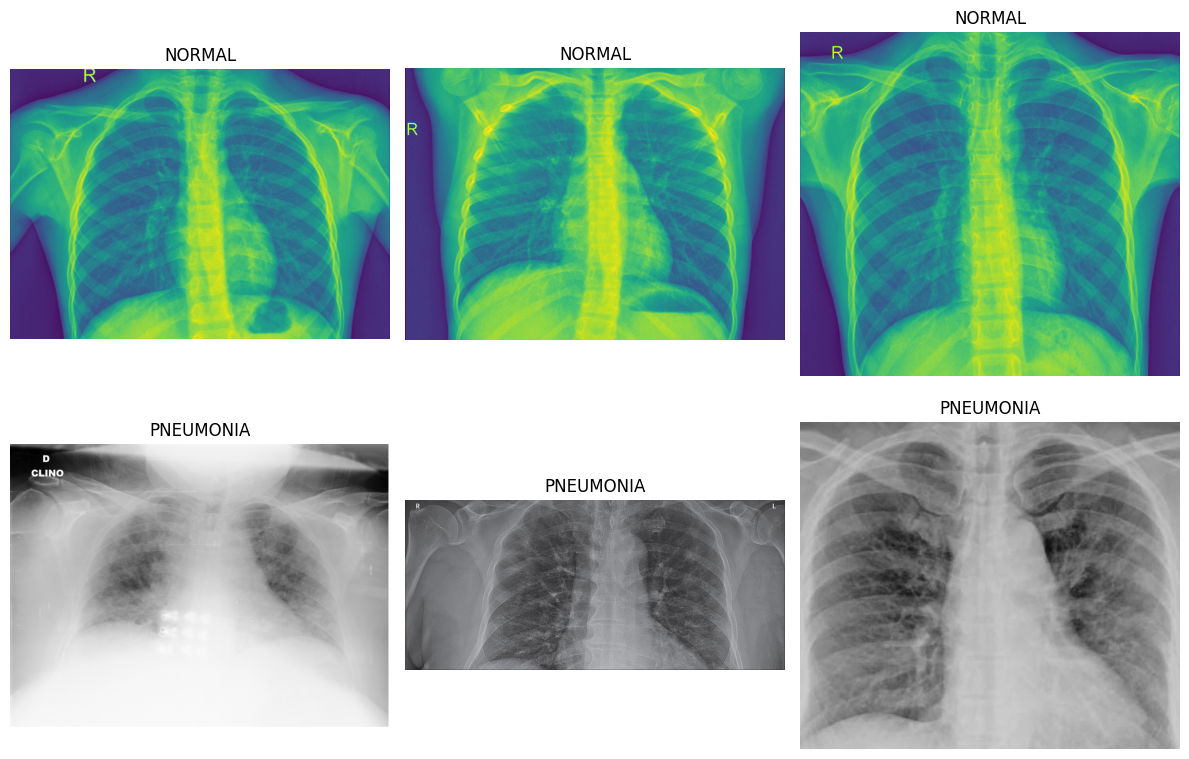

In [6]:
dataset = datasets.ImageFolder(train_dir, transform=transforms.ToTensor())

idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
samples_per_class = 3
class_samples = {cls: [] for cls in dataset.classes}

for img_path, label in dataset.samples:
    class_name = idx_to_class[label]
    if len(class_samples[class_name]) < samples_per_class:
        class_samples[class_name].append(img_path)

plt.figure(figsize=(12, 8))
for i, (cls, img_paths) in enumerate(class_samples.items()):
    for j, img_path in enumerate(img_paths):
        plt.subplot(len(dataset.classes), samples_per_class, i * samples_per_class + j + 1)
        img = plt.imread(img_path)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Train dataset
train_dataset = ImageFolder(root=train_dir, transform=transform_train)

# Split into train and validation (80% train, 20% validation)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Test dataset
test_dataset = ImageFolder(root=test_dir, transform=transform_val_test)

# Create DataLoader for train, validation, and test datasets
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. Model Setup
- Define the custom CNN model
- Load pre-trained ResNet50 model later and modify its final layer

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Define the CNN Architecture

In [9]:
class Covid19CNN(nn.Module):
    def __init__(self):
        super(Covid19CNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Dropout(0.2),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.Dropout(0.3),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),  
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

# 4. Training and Testing (both CNN & ResNet)
- Iterate through epochs to train the model.
- Track and display training loss and accuracy.
- Perform validation after each epoch.
- Save the model with the best validation accuracy.

## CNN model

In [ ]:
cnn_model = Covid19CNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=5, min_lr=1e-6)

best_val_loss = np.inf
patience, counter = 5, 0
cnn_train_losses, cnn_val_losses = [], []
cnn_train_accuracies, cnn_val_accuracies = [], []

for epoch in range(10):
    cnn_model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/10"):
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

    train_acc = 100 * correct / total
    avg_train_loss = total_loss / len(train_loader)

    # Validation
    cnn_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = cnn_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    scheduler.step(avg_val_loss)

    cnn_train_losses.append(avg_train_loss)
    cnn_val_losses.append(val_loss / len(val_loader))
    cnn_train_accuracies.append(train_acc)
    cnn_val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/10] Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% "
            f"| Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(cnn_model.state_dict(), "best_model.pth")
        print("✅ Model saved (improved validation loss)")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("⏹️ Early stopping triggered.")
            break

Epoch 1/10: 100%|██████████| 4/4 [00:04<00:00,  1.20s/it]


Epoch [1/10] Train Loss: 0.4388 | Train Acc: 77.12% | Val Loss: 0.4937 | Val Acc: 86.67%
✅ Model saved (improved validation loss)


Epoch 2/10: 100%|██████████| 4/4 [00:04<00:00,  1.08s/it]


Epoch [2/10] Train Loss: 0.1221 | Train Acc: 95.76% | Val Loss: 0.3727 | Val Acc: 86.67%
✅ Model saved (improved validation loss)


Epoch 3/10: 100%|██████████| 4/4 [00:04<00:00,  1.06s/it]


...

Epoch [8/10] Train Loss: 0.0362 | Train Acc: 98.31% | Val Loss: 0.0081 | Val Acc: 100.00%
✅ Model saved (improved validation loss)


Epoch 9/10: 100%|██████████| 4/4 [00:04<00:00,  1.06s/it]


Epoch [9/10] Train Loss: 0.0017 | Train Acc: 100.00% | Val Loss: 0.0038 | Val Acc: 100.00%
✅ Model saved (improved validation loss)


Epoch 10/10: 100%|██████████| 4/4 [00:04<00:00,  1.08s/it]


Epoch [10/10] Train Loss: 0.0176 | Train Acc: 99.15% | Val Loss: 0.0085 | Val Acc: 100.00%


In [11]:
cnn_model.load_state_dict(torch.load("best_model.pth"))
cnn_model.eval()

correct, total, test_loss = 0, 0, 0
criterion = nn.BCEWithLogitsLoss()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"\n✅ Test Accuracy: {100 * correct / total:.2f}% | Test Loss: {test_loss / len(test_loader):.4f}")

cnn_test_acc = 100 * correct / total
cnn_test_loss = test_loss / len(test_loader)


✅ Test Accuracy: 100.00% | Test Loss: 0.0112


## Resnet 50

In [12]:
resnet = models.resnet50(pretrained=True)
for param in resnet.parameters():
    param.requires_grad = False  # freeze feature extractor

# replace last layer (for binary classification)
num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 1)
)

resnet = resnet.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
optimizer = optim.Adam(resnet.fc.parameters(), lr=1e-4, weight_decay=1e-5)

best_val_loss = np.inf
patience, counter = 5, 0
num_epochs = 10

resnet_train_losses, resnet_val_losses = [], []
resnet_train_accuracies, resnet_val_accuracies = [], []

for epoch in range(num_epochs):
    resnet.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

    train_acc = 100 * correct / total
    avg_train_loss = total_loss / len(train_loader)

    # Validation
    resnet.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = resnet(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    scheduler.step(avg_val_loss)

    resnet_train_losses.append(avg_train_loss)
    resnet_val_losses.append(val_loss / len(val_loader))
    resnet_train_accuracies.append(train_acc)
    resnet_val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(resnet.state_dict(), "best_resnet_model.pth")
        print("✅ Model saved (improved validation loss)")
        counter = 0
    else:
        counter += 1
        print(f"⚠️ Early stopping counter: {counter}/{patience}")
        if counter >= patience:
            print("⏹️ Early stopping triggered.")
            break

Epoch 1/10: 100%|██████████| 4/4 [00:04<00:00,  1.11s/it]


Epoch [1/10] Train Loss: 0.6867 | Train Acc: 52.54% | Val Loss: 0.6552 | Val Acc: 63.33%
✅ Model saved (improved validation loss)


Epoch 2/10: 100%|██████████| 4/4 [00:04<00:00,  1.10s/it]


Epoch [2/10] Train Loss: 0.6494 | Train Acc: 74.58% | Val Loss: 0.6181 | Val Acc: 90.00%
✅ Model saved (improved validation loss)


Epoch 3/10: 100%|██████████| 4/4 [00:04<00:00,  1.11s/it]


...

Epoch [8/10] Train Loss: 0.4312 | Train Acc: 93.22% | Val Loss: 0.4742 | Val Acc: 93.33%
✅ Model saved (improved validation loss)


Epoch 9/10: 100%|██████████| 4/4 [00:04<00:00,  1.12s/it]


Epoch [9/10] Train Loss: 0.4050 | Train Acc: 90.68% | Val Loss: 0.4374 | Val Acc: 90.00%
✅ Model saved (improved validation loss)


Epoch 10/10: 100%|██████████| 4/4 [00:04<00:00,  1.11s/it]


Epoch [10/10] Train Loss: 0.3905 | Train Acc: 95.76% | Val Loss: 0.3901 | Val Acc: 90.00%
✅ Model saved (improved validation loss)


In [14]:
resnet.load_state_dict(torch.load("best_resnet_model.pth"))
resnet.eval()

correct, total, test_loss = 0, 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"\n✅ Test Accuracy: {100 * correct / total:.2f}% | Test Loss: {test_loss / len(test_loader):.4f}")

resnet_test_acc = 100 * correct / total
resnet_test_loss = test_loss / len(test_loader)


✅ Test Accuracy: 97.50% | Test Loss: 0.4099


In [15]:
results = {
    "CNN": {
        "train_acc": cnn_train_accuracies,
        "val_acc": cnn_val_accuracies,
        "train_loss": cnn_train_losses,
        "val_loss": cnn_val_losses,
        "test_acc": cnn_test_acc,
        "test_loss": cnn_test_loss,
    },
    "ResNet": {
        "train_acc": resnet_train_accuracies,
        "val_acc": resnet_val_accuracies,
        "train_loss": resnet_train_losses,
        "val_loss": resnet_val_losses,
        "test_acc": resnet_test_acc,
        "test_loss": resnet_test_loss,
    }
}

# 5. Plotting Metrics
- Plot training and validation accuracy and loss curves.

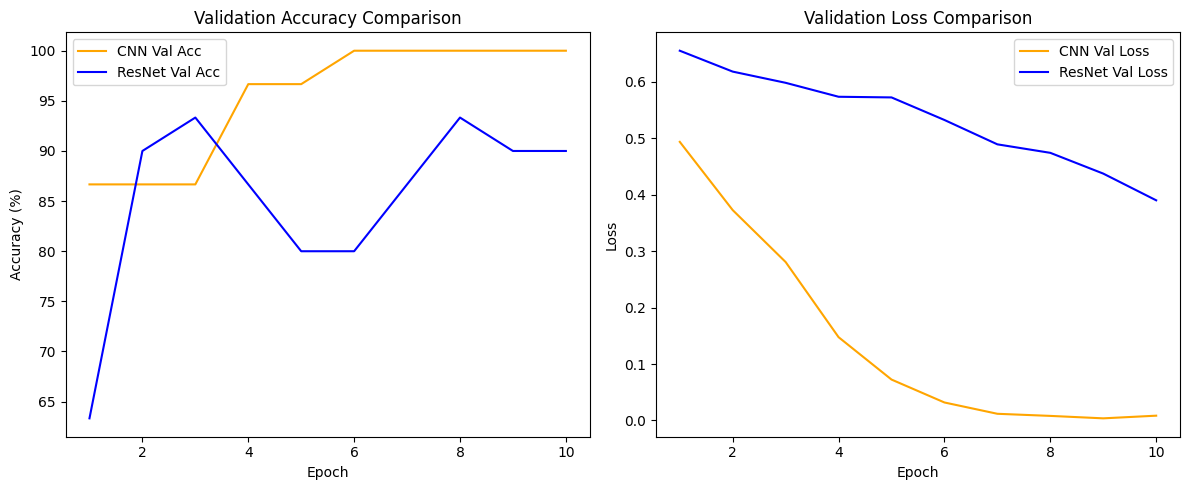

In [16]:
# ======================================
# 🧠 2. Compare training curves
# ======================================
epochs = list(range(1, len(results["CNN"]["train_acc"]) + 1))
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, results["CNN"]["val_acc"], label="CNN Val Acc", color="orange")
plt.plot(epochs, results["ResNet"]["val_acc"], label="ResNet Val Acc", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy Comparison")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, results["CNN"]["val_loss"], label="CNN Val Loss", color="orange")
plt.plot(epochs, results["ResNet"]["val_loss"], label="ResNet Val Loss", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Comparison")
plt.legend()

plt.tight_layout()
plt.show()

# 6. Confusion Matrix
- Plot the confusion matrix to visualize model performance.

🔹 Final Model Comparison:
  CNN Test Accuracy:    100.00% | Test Loss: 0.0112
  ResNet Test Accuracy: 97.50% | Test Loss: 0.4099

🏆 The better model based on test accuracy is: CNN


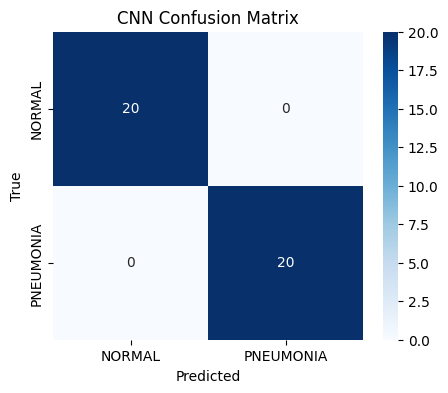

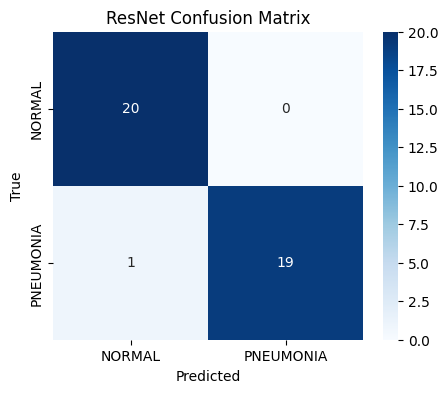

In [17]:
# ======================================
# 🏁 3. Print test performance comparison
# ======================================

print("🔹 Final Model Comparison:")
print(f"  CNN Test Accuracy:    {results['CNN']['test_acc']:.2f}% | Test Loss: {results['CNN']['test_loss']:.4f}")
print(f"  ResNet Test Accuracy: {results['ResNet']['test_acc']:.2f}% | Test Loss: {results['ResNet']['test_loss']:.4f}")

better_model = "ResNet" if results['ResNet']['test_acc'] > results['CNN']['test_acc'] else "CNN"
print(f"\n🏆 The better model based on test accuracy is: {better_model}")

# ======================================
# 📈 4. Optional – visualize confusion matrix for both
# ======================================

def plot_conf_matrix(model, test_loader, classes, title):
    all_labels, all_preds = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_conf_matrix(cnn_model, test_loader, test_dataset.classes, "CNN Confusion Matrix")
plot_conf_matrix(resnet, test_loader, test_dataset.classes, "ResNet Confusion Matrix")

# 7. Random Image Visualizations
- Select random images from the test set and display them with true and predicted labels.

In [18]:
def visualize_model_comparison(cnn_model, resnet_model, test_dataset, device, classes, num_samples=12):
    cnn_model.eval()
    resnet_model.eval()
    
    random_indices = random.sample(range(len(test_dataset)), num_samples)
    images, labels = zip(*[test_dataset[i] for i in random_indices])
    images = torch.stack(images)
    labels = torch.tensor(labels)

    with torch.no_grad():
        cnn_outputs = cnn_model(images.to(device))
        resnet_outputs = resnet_model(images.to(device))
        
        cnn_preds = (torch.sigmoid(cnn_outputs) > 0.5).long().squeeze(1)
        resnet_preds = (torch.sigmoid(resnet_outputs) > 0.5).long().squeeze(1)

    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    cnn_preds = cnn_preds.cpu().numpy()
    resnet_preds = resnet_preds.cpu().numpy()

    num_cols = 4
    num_rows = (num_samples + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 3.5 * num_rows))
    axes = axes.flatten()

    for i in range(num_samples):
        ax = axes[i]
        img = images[i].transpose(1, 2, 0)
        # reverse normalization
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.axis('off')

        true_label = classes[labels[i]]
        cnn_label = classes[cnn_preds[i]]
        resnet_label = classes[resnet_preds[i]]

        color_cnn = "green" if labels[i] == cnn_preds[i] else "red"
        color_resnet = "green" if labels[i] == resnet_preds[i] else "red"

        ax.set_title(
            f"True: {true_label}\n"
            f"CNN: {cnn_label}\n"
            f"ResNet: {resnet_label}",
            color="black", fontsize=10
        )

    plt.tight_layout()
    plt.show()

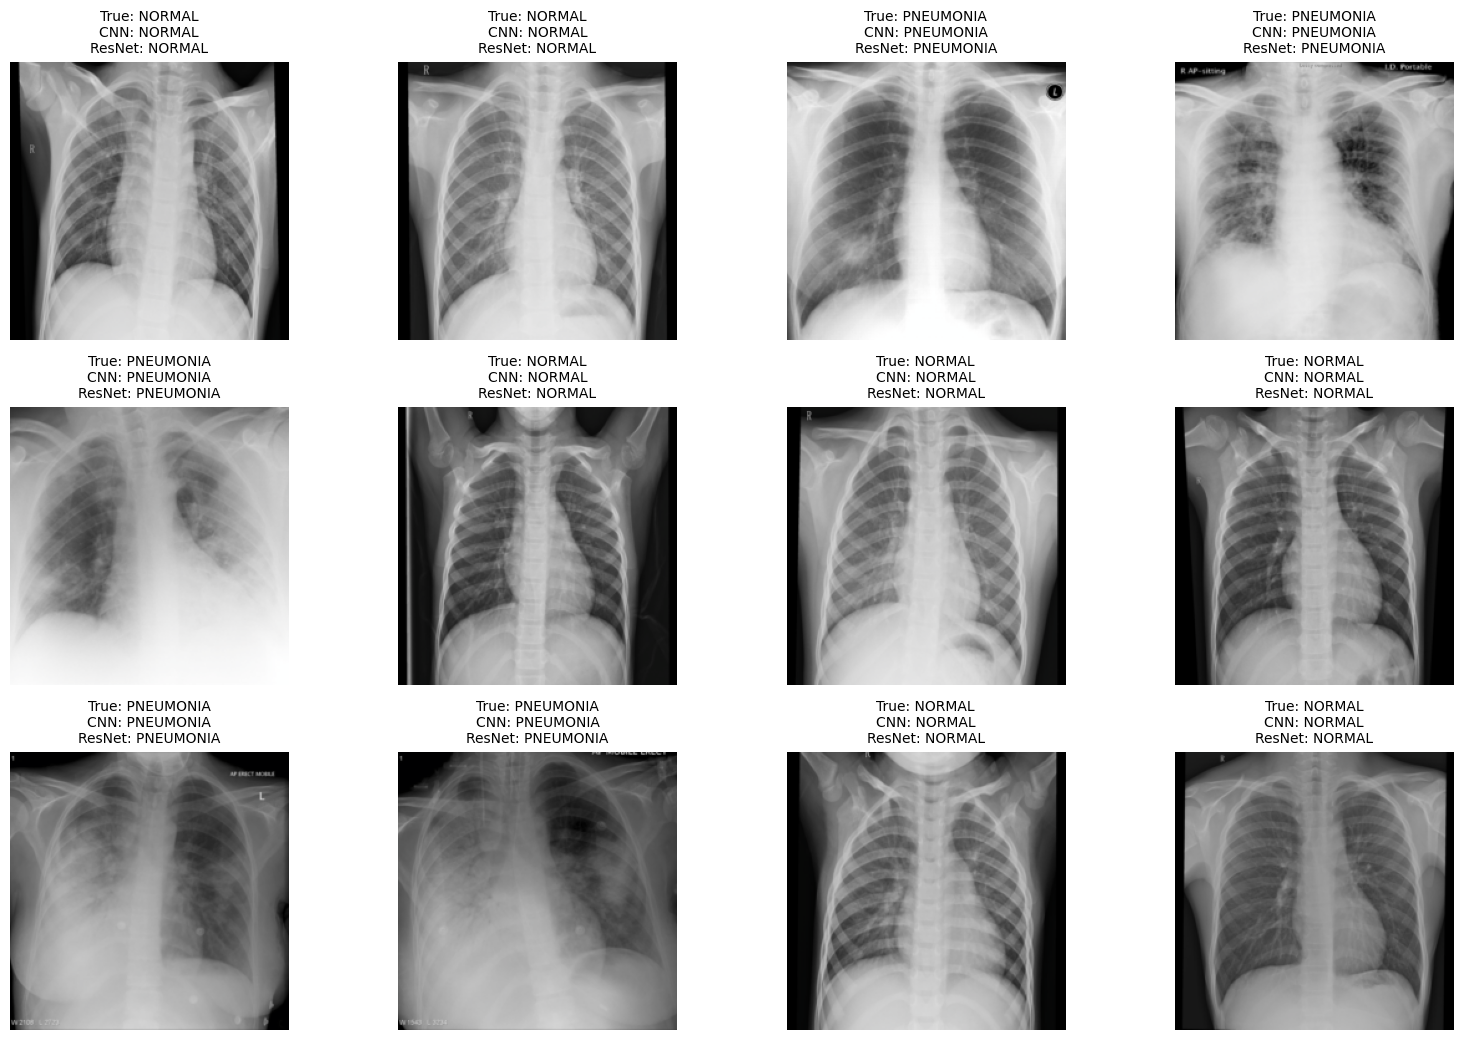

In [19]:
classes = ['NORMAL', 'PNEUMONIA']
visualize_model_comparison(cnn_model, resnet, test_dataset, device, classes, num_samples=12)